In [1]:
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import mean_squared_log_error, mean_squared_error

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

In [5]:
%pip install catboost

  Using cached graphviz-0.20.3-py3-none-any.whl.metadata (12 kB)
   ---------------------------------------- 0.0/102.4 MB ? eta -:--:--
   ---------------------------------------- 0.5/102.4 MB 4.2 MB/s eta 0:00:25
    --------------------------------------- 1.8/102.4 MB 5.6 MB/s eta 0:00:18
   - -------------------------------------- 3.1/102.4 MB 6.0 MB/s eta 0:00:17
   - -------------------------------------- 4.2/102.4 MB 5.9 MB/s eta 0:00:17
   - -------------------------------------- 4.7/102.4 MB 5.0 MB/s eta 0:00:20
   - -------------------------------------- 5.0/102.4 MB 5.0 MB/s eta 0:00:20
   -- ------------------------------------- 5.2/102.4 MB 3.8 MB/s eta 0:00:26
   -- ------------------------------------- 6.3/102.4 MB 4.0 MB/s eta 0:00:25
   -- ------------------------------------- 7.6/102.4 MB 4.4 MB/s eta 0:00:22
   --- ------------------------------------ 8.9/102.4 MB 4.5 MB/s eta 0:00:21
   --- ------------------------------------ 10.2/102.4 MB 4.7 MB/s eta 0:00:20
   --

In [2]:
from catboost import CatBoostRegressor

In [3]:
## Path

path  = 'data/'

In [4]:
## Data

train = pd.read_csv(path + 'train.csv')

test = pd.read_csv(path + 'test.csv')

submission = pd.read_csv(path + 'sample_submission.csv')

In [5]:
# === Basic Preprocessing ===
train['Sex'] = train['Sex'].map({'male': 1, 'female': 0})
test['Sex'] = test['Sex'].map({'male': 1, 'female': 0})
train = train.drop_duplicates(subset=train.columns).reset_index(drop=True)
train = train.groupby(['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp'])['Calories'].min().reset_index()

In [6]:
# === Feature Engineering ===
def add_features(df):
    df['BMI'] = df['Weight'] / (df['Height'] / 100) ** 2
    df['Intensity'] = df['Heart_Rate'] / df['Duration']

    df['Sex_Reversed'] = 1 - df['Sex']
    for dur in df['Duration'].unique():
        df[f'HR_Dur_{int(dur)}'] = np.where(df['Duration'] == dur, df['Heart_Rate'], 0)
        df[f'Temp_Dur_{int(dur)}'] = np.where(df['Duration'] == dur, df['Body_Temp'], 0)
    for age in df['Age'].unique():
        df[f'HR_Age_{int(age)}'] = np.where(df['Age'] == age, df['Heart_Rate'], 0)
        df[f'Temp_Age_{int(age)}'] = np.where(df['Age'] == age, df['Body_Temp'], 0)

    for f1 in ['Duration', 'Heart_Rate', 'Body_Temp']:
        for f2 in ['Sex', 'Sex_Reversed']:
            df[f'{f1}_x_{f2}'] = df[f1] * df[f2]

    for col in ['Height', 'Weight', 'Heart_Rate', 'Body_Temp']:
        for agg in ['min', 'max']:
            agg_val = train.groupby('Sex')[col].agg(agg).rename(f'Sex_{col}_{agg}')
            df = df.merge(agg_val, on='Sex', how='left')

    df.drop(columns=['Sex_Reversed'], inplace=True)
    return df

train = add_features(train)
test = add_features(test)

In [7]:
# === Align Columns ===
common_cols = [col for col in test.columns if col in train.columns and col != 'Calories']
X = train[common_cols]

print(X.columns)

y = np.log1p(train['Calories'])
X_test = test[common_cols]

Index(['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp',
       'BMI', 'Intensity', 'HR_Dur_7',
       ...
       'Body_Temp_x_Sex', 'Body_Temp_x_Sex_Reversed', 'Sex_Height_min',
       'Sex_Height_max', 'Sex_Weight_min', 'Sex_Weight_max',
       'Sex_Heart_Rate_min', 'Sex_Heart_Rate_max', 'Sex_Body_Temp_min',
       'Sex_Body_Temp_max'],
      dtype='object', length=203)


In [9]:
# === CatBoost Training (StratifiedKFold on Duration bins) ===
bins = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
duration_bins = bins.fit_transform(train[['Duration']]).astype(int).flatten()

cat_params = {
    'iterations': 2500,
    'learning_rate': 0.02,
    'depth': 10,
    'loss_function': 'RMSE',
    'l2_leaf_reg': 3,
    'random_seed': 42,
    'eval_metric': 'RMSE',
    'early_stopping_rounds': 200,
    'cat_features': ['Sex'],
    'verbose': 0,
    'task_type': 'GPU'
}

cat_preds = np.zeros(len(X_test))
cat_oof = np.zeros(len(X))
cat_scores = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, duration_bins)):
    model = CatBoostRegressor(**cat_params)
    model.fit(X.iloc[train_idx], y.iloc[train_idx], eval_set=(X.iloc[val_idx], y.iloc[val_idx]), use_best_model=True)
    cat_oof[val_idx] = model.predict(X.iloc[val_idx])
    cat_preds += model.predict(X_test) / skf.n_splits
    fold_score = np.sqrt(mean_squared_log_error(np.expm1(y.iloc[val_idx]), np.expm1(cat_oof[val_idx])))
    print(f"Fold {fold+1} - CatBoost RMSLE: {fold_score:.5f}")
    cat_scores.append(fold_score)

# Train on the full dataset to get predictions for all of `X`
final_model = CatBoostRegressor(**cat_params)
final_model.fit(X, y)  # Train on entire dataset
cat_train_preds = final_model.predict(X)  # Full train predictions

print(f"\n CatBoost Mean RMSLE: {np.mean(cat_scores):.5f}")

Fold 1 - CatBoost RMSLE: 0.06002
Fold 2 - CatBoost RMSLE: 0.05952
Fold 3 - CatBoost RMSLE: 0.05933
Fold 4 - CatBoost RMSLE: 0.05944
Fold 5 - CatBoost RMSLE: 0.06022

 CatBoost Mean RMSLE: 0.05970


In [ ]:
# === XGBoost Training (Standard KFold) ===
X_xgb = X.copy()
X_test_xgb = X_test.copy()
X_xgb['Sex'] = X_xgb['Sex'].astype(int)
X_test_xgb['Sex'] = X_test_xgb['Sex'].astype(int)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_oof = np.zeros(len(train))
xgb_preds = np.zeros(len(test))
xgb_scores = []

xgb_params = {
    'max_depth': 9,
    'colsample_bytree': 0.7,
    'subsample': 0.9,
    'n_estimators': 3000,
    'learning_rate': 0.01,
    'gamma': 0.01,
    'max_delta_step': 2,
    'eval_metric': 'rmse',
    'enable_categorical': False,
    'random_state': 42,
    'early_stopping_rounds': 100,
    'tree_method': 'gpu_hist'
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_xgb)):
    model = XGBRegressor(**xgb_params)
    model.fit(X_xgb.iloc[train_idx], y.iloc[train_idx], eval_set=[(X_xgb.iloc[val_idx], y.iloc[val_idx])], verbose=False)
    xgb_oof[val_idx] = model.predict(X_xgb.iloc[val_idx])
    xgb_preds += model.predict(X_test_xgb) / kf.n_splits
    fold_score = np.sqrt(mean_squared_log_error(np.expm1(y.iloc[val_idx]), np.expm1(xgb_oof[val_idx])))
    print(f"Fold {fold+1} - XGBoost RMSLE: {fold_score:.5f}")
    xgb_scores.append(fold_score)
    




Fold 1 - XGBoost RMSLE: 0.05946
Fold 2 - XGBoost RMSLE: 0.06034
Fold 3 - XGBoost RMSLE: 0.06024
Fold 4 - XGBoost RMSLE: 0.05913
Fold 5 - XGBoost RMSLE: 0.06079


ValueError: Must have at least 1 validation dataset for early stopping.

In [11]:
print(f"\n XGBoost Mean RMSLE: {np.mean(xgb_scores):.5f}")


 XGBoost Mean RMSLE: 0.05999


In [12]:
final_model = XGBRegressor(**xgb_params)

# Remove early stopping rounds when training on full dataset
final_model.fit(X, y, eval_set=[(X, y)], verbose=False)

xgb_train_preds = final_model.predict(X) 

In [14]:

print("Final Predictions:", y_final)

Final Predictions: [4.20378509 1.72589314 4.98223744 ... 5.11154693 5.17493629 5.3648747 ]


In [15]:
# === Final Blend (Weighted Average) ===
final_preds = 0.49 * np.expm1(xgb_preds) + 0.51 * np.expm1(cat_preds)
submission['Calories'] = np.clip(final_preds, 1, 314)
submission.to_csv('submission.csv', index=False)
print("\n submission.csv saved ")


 submission.csv saved 


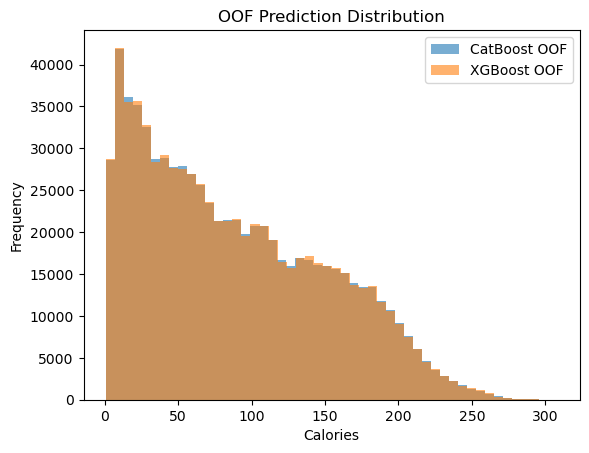


 Final Submission Preview:
                  id       Calories
count  250000.000000  250000.000000
mean   874999.500000      88.161868
std     72168.927986      62.258244
min    750000.000000       1.045776
25%    812499.750000      34.007650
50%    874999.500000      76.437043
75%    937499.250000     135.345539
max    999999.000000     302.915569
       id    Calories
0  750000   27.189134
1  750001  108.292981
2  750002   87.532953
3  750003  125.666613
4  750004   76.274241


In [15]:
# === Diagnostics ===
plt.hist(np.expm1(cat_oof), bins=50, alpha=0.6, label='CatBoost OOF')
plt.hist(np.expm1(xgb_oof), bins=50, alpha=0.6, label='XGBoost OOF')
plt.title("OOF Prediction Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.legend()
plt.show()

print("\n Final Submission Preview:")
print(submission.describe())
print(submission.head())